In [1]:
import time as tm
import pandas as pd
import geopandas as gpd

## MILP & Branch and Bound

This section formulates and solves the core optimization problem as a Mixed-Integer Linear Program (MILP). The objective is to minimize the total risk-weighted operational distance across all Istanbul grid cells by deciding which helipad stations receive a helicopter and which grid cells are assigned to which station.

### Decision Variables
- **x[i, k] ∈ {0, 1}:** Whether a helicopter of type k is placed at station i
- **z[i, j] ∈ {0, 1}:** Whether grid cell j is served by station i

### Objective Function
$$\min \sum_{i \in I} \sum_{j \in J} R_j \cdot D_{ij} \cdot z_{ij}$$

### Constraints
-Every risky grid cell must be assigned to exactly one station |
-Total helicopter procurement cost must not exceed $311M |
-Each helipad can host at most 1 helicopter |
-One helicopter can cover at most 20 grid cells |
-A station can only serve grids if it has a helicopter |
-A station cannot serve a grid beyond 150 km |

The model is solved using the GLPK solver via PuLP. The same formulation is then used in the Branch & Bound scalability benchmark in Part 2.

In [2]:
from pulp import (
    LpProblem, LpVariable, LpBinary, LpInteger,
    LpMinimize, lpSum, GLPK_CMD, LpStatus, value,
)

# Problem parameters
BUDGET               = 311    # total procurement budget (million $)
MAX_STATION_CAPACITY = 1      # max 1 helicopter per helipad
MAX_ASSIGN_PER_HELI  = 20     # max grid cells one helicopter can cover
DISTANCE_LIMIT_KM    = 150.0  # operational range limit (km)

# Helicopter type specifications: cost and water tank capacity
HELI_TYPES = {
    "Type_1": {"cost": 30, "water": 700},
    "Type_2": {"cost": 10, "water": 300},
    "Type_3": {"cost":  4, "water": 180},
}

### Data Loading

The precomputed R_j and D_ij matrices are loaded directly from CSV files produced in the data preparation stage. This keeps the optimization stage fully decoupled from geospatial preprocessing.

In [3]:
def load_data():
    df_risk      = pd.read_csv("Rj_Risk_Matrix.csv")
    risk_by_grid = df_risk.set_index("Grid_ID")["R_j"].to_dict()
    grid_ids     = sorted(risk_by_grid.keys())

    # Load distance matrix and build a (Station_ID, Grid_ID) : D_ij dictionary
    df_dist      = pd.read_csv("Dij_Distance_Matrix.csv")
    dist_by_pair = {
        (r.Station_ID, r.Grid_ID): r.D_ij_km
        for r in df_dist.itertuples(index=False)
    }
    station_ids  = sorted(df_dist["Station_ID"].unique())

    print(f"  Stations : {len(station_ids)}")
    print(f"  Grids    : {len(grid_ids)}")
    print(f"  Risky grids (R_j > 0): {sum(1 for v in risk_by_grid.values() if v > 0)}")

    return station_ids, grid_ids, risk_by_grid, dist_by_pair

### MILP Model Builder

The `build_milp` function constructs the full PuLP model with all six constraints. It is shared between the full MILP solve and the Branch & Bound benchmark.

In [4]:
def build_milp(station_ids, grid_ids, risk_by_grid, dist_by_pair,
               model_name="HeliFire_MILP"):

    model = LpProblem(model_name, LpMinimize)

    # x[i, k]: binary — 1 if helicopter type k is assigned to station i
    # upBound=1 enforces the single-helicopter-per-pad capacity constraint
    x = {
        (i, k): LpVariable(f"x_{i}_{k}", lowBound=0, upBound=MAX_STATION_CAPACITY,
                            cat=LpInteger)
        for i in station_ids
        for k in HELI_TYPES
    }

    # z[i, j]: binary — 1 if grid cell j is served by station i
    z = {
        (i, j): LpVariable(f"z_{i}_{j}", cat=LpBinary)
        for i in station_ids
        for j in grid_ids
    }

    # Objective: minimize total risk-weighted operational distance
    model += lpSum(
        risk_by_grid[j] * dist_by_pair[(i, j)] * z[(i, j)]
        for i in station_ids
        for j in grid_ids
        if risk_by_grid.get(j, 0) > 0 and (i, j) in dist_by_pair
    ), "Minimize_RiskWeightedDistance"

    # C1: Full coverage — each risky grid must be assigned to exactly one station
    #     Non-risky grids are explicitly forced to zero to keep the model clean
    for j in grid_ids:
        if risk_by_grid.get(j, 0) > 0:
            model += (
                lpSum(z[(i, j)] for i in station_ids) == 1,
                f"C1_Coverage_{j}"
            )
        else:
            for i in station_ids:
                model += z[(i, j)] == 0, f"C1_NoRisk_{i}_{j}"

    # C2: Budget — total procurement cost of all helicopters must not exceed BUDGET
    model += (
        lpSum(HELI_TYPES[k]["cost"] * x[(i, k)]
              for i in station_ids for k in HELI_TYPES) <= BUDGET,
        "C2_Budget"
    )

    # C3: Station capacity — at most one helicopter per helipad
    for i in station_ids:
        model += (
            lpSum(x[(i, k)] for k in HELI_TYPES) <= MAX_STATION_CAPACITY,
            f"C3_Capacity_{i}"
        )

    # C4: Assignment cap — one helicopter can cover at most MAX_ASSIGN_PER_HELI grids
    for i in station_ids:
        model += (
            lpSum(z[(i, j)] for j in grid_ids)
            <= MAX_ASSIGN_PER_HELI * lpSum(x[(i, k)] for k in HELI_TYPES),
            f"C4_AssignCap_{i}"
        )

    # C5 & C6: Per station-grid pair constraints
    for i in station_ids:
        for j in grid_ids:
            # C5: Activation link — cannot assign a grid to a station with no helicopter
            model += (
                z[(i, j)] <= lpSum(x[(i, k)] for k in HELI_TYPES),
                f"C5_Activation_{i}_{j}"
            )
            # C6: Distance limit — assignment is forbidden if station is out of range
            d = dist_by_pair.get((i, j), float("inf"))
            if d > DISTANCE_LIMIT_KM:
                model += z[(i, j)] == 0, f"C6_Range_{i}_{j}"

    return model, x, z

### Results Printer

A shared utility function that extracts and displays the solution after any solve call — used by both Part 1 and Part 2.

In [5]:
def print_results(model, x, z, station_ids, grid_ids,
                  risk_by_grid, dist_by_pair, exec_time, label="MILP"):

    status = LpStatus[model.status]
    obj    = value(model.objective) if model.status == 1 else None

    print(f"\n{'='*58}")
    print(f"  {label} RESULT")
    print(f"{'='*58}")
    print(f"  Status          : {status}")
    print(f"  Computing Time  : {exec_time:.3f} seconds")

    if model.status != 1:
        print("  No optimal solution found.")
        return

    print(f"  Objective Value : {obj:.4f}")

    # Helicopter allocations and total spending
    total_spent     = 0
    total_water     = 0
    active_stations = []

    for i in station_ids:
        for k in HELI_TYPES:
            cnt = int(round(value(x[(i, k)]) or 0))
            if cnt > 0:
                total_spent += cnt * HELI_TYPES[k]["cost"]
                total_water += cnt * HELI_TYPES[k]["water"]
                active_stations.append((i, k, cnt))

    # Check which risky grids are covered and which are not
    assigned_grids   = []
    unassigned_risky = []
    for j in grid_ids:
        if risk_by_grid.get(j, 0) <= 0:
            continue
        covered = any(round(value(z[(i, j)]) or 0) == 1 for i in station_ids)
        if covered:
            assigned_grids.append(j)
        else:
            unassigned_risky.append(j)

    print(f"  Budget Spent    : ${total_spent}M / ${BUDGET}M")
    print(f"  Total Water Cap : {total_water} gallons")
    print(f"  Active Stations : {len(active_stations)}")
    print(f"  Assigned Grids  : {len(assigned_grids)}")
    print(f"  Unassigned Risky: {len(unassigned_risky)}")

    print(f"\n{'─'*58}")
    print(f"  HELICOPTER ALLOCATION")
    print(f"{'─'*58}")
    print(f"  {'Station':<10} {'Type':<10} {'Water (gal)':<14} {'Cost ($M)'}")

    # Print per-station allocation and accumulate type-level totals
    type_totals = {k: 0 for k in HELI_TYPES}
    for i, k, cnt in sorted(active_stations, key=lambda r: r[0]):
        w = HELI_TYPES[k]["water"] * cnt
        c = HELI_TYPES[k]["cost"]  * cnt
        print(f"  {i:<10} {k:<10} {w:<14} {c}")
        type_totals[k] += cnt

    print(f"\n  Summary by type:")
    for k, total in type_totals.items():
        print(f"    {k}: {total} unit(s) — "
              f"{total * HELI_TYPES[k]['water']} gal — "
              f"${total * HELI_TYPES[k]['cost']}M")

### Part 1 — Full MILP Solution

The problem is solved over all risky grid cells and all helipad stations. The GLPK solver applies Branch & Bound internally to find the globally optimal helicopter allocation within the given time limit.

In [6]:
def run_milp(station_ids, top_grids, risk_by_grid, dist_by_pair, time_limit=300):

    print(f"\n{'─'*58}")
    print(f"  PART 1: MILP (GLPK solver, time limit={time_limit}s)")
    print(f"  {len(station_ids)} stations × {len(top_grids)} risky grids")
    print(f"{'─'*58}")

    model, x, z = build_milp(station_ids, top_grids, risk_by_grid, dist_by_pair,
                              model_name="HeliFire_MILP")

    print(f"  Variables  : {len(model.variables())}")
    print(f"  Constraints: {len(model.constraints)}")

    t0 = tm.perf_counter()
    model.solve(GLPK_CMD(msg=True, timeLimit=time_limit))
    elapsed = tm.perf_counter() - t0

    print_results(model, x, z, station_ids, top_grids,
                  risk_by_grid, dist_by_pair, elapsed, label="MILP")

    return model, x, z


# Load data and run
station_ids, grid_ids, risk_by_grid, dist_by_pair = load_data()
top_grids = [j for j in grid_ids if risk_by_grid.get(j, 0) > 0]

print(f"Problem scope: {len(station_ids)} stations, {len(top_grids)} risky grids")
print(f"Budget: ${BUDGET}M | Capacity: {MAX_STATION_CAPACITY} heli/pad | Range: {DISTANCE_LIMIT_KM} km\n")

milp_model, x, z = run_milp(station_ids, top_grids, risk_by_grid, dist_by_pair, time_limit=300)

  Stations : 184
  Grids    : 3420
  Risky grids (R_j > 0): 294
Problem scope: 184 stations, 294 risky grids
Budget: $311M | Capacity: 1 heli/pad | Range: 150.0 km


──────────────────────────────────────────────────────────
  PART 1: MILP (GLPK solver, time limit=300s)
  184 stations × 294 risky grids
──────────────────────────────────────────────────────────
  Variables  : 54648
  Constraints: 54759

  MILP RESULT
  Status          : Optimal
  Computing Time  : 18.441 seconds
  Objective Value : 655.4786
  Budget Spent    : $304M / $311M
  Total Water Cap : 7680 gallons
  Active Stations : 16
  Assigned Grids  : 294
  Unassigned Risky: 0

──────────────────────────────────────────────────────────
  HELICOPTER ALLOCATION
──────────────────────────────────────────────────────────
  Station    Type       Water (gal)    Cost ($M)
  0          Type_1     700            30
  2          Type_3     180            4
  4          Type_3     180            4
  9          Type_1     700         

### Part 2 — Branch & Bound Scalability Benchmark

To demonstrate why exact methods become impractical at scale, the same MILP formulation is solved repeatedly at increasing problem sizes (10, 25, 50, 100, and all risky grids). Solve time and solution status are recorded at each scale.

In [7]:
def run_branch_and_bound(station_ids, top_grids, risk_by_grid, dist_by_pair, time_limit=120):

    print(f"\n{'─'*58}")
    print(f"  PART 2: BRANCH & BOUND SCALABILITY BENCHMARK")
    print(f"  (Same MILP model, increasing problem size)")
    print(f"{'─'*58}\n")

    # Defining problem sizes to benchmark, cap at the actual number of risky grids
    scenarios = sorted(set(s for s in [10, 25, 50, 100, len(top_grids)]
                           if s <= len(top_grids)))
    results = []

    for n in scenarios:
        # Take the first n risky grids (sorted by Grid_ID for reproducibility)
        sub_grids = top_grids[:n]
        print(f" Solving: {len(station_ids)} stations × {n} grids ...", end=" ", flush=True)

        model, x, z = build_milp(
            station_ids, sub_grids, risk_by_grid, dist_by_pair,
            model_name=f"BB_{n}grids"
        )

        t0 = tm.perf_counter()
        model.solve(GLPK_CMD(msg=False, timeLimit=time_limit))
        elapsed = tm.perf_counter() - t0

        status = LpStatus[model.status]
        obj    = round(value(model.objective), 4) if model.status == 1 else None

        # Counting total helicopters deployed in this sub-problem solution
        n_heli = sum(
            int(round(value(x[(i, k)]) or 0))
            for i in station_ids for k in HELI_TYPES
        ) if model.status == 1 else None

        results.append({
            "Grids"      : n,
            "Variables"  : len(model.variables()),
            "Constraints": len(model.constraints),
            "Status"     : status,
            "Objective"  : obj,
            "Helis"      : n_heli,
            "Time (s)"   : round(elapsed, 3),
        })

        print(f"done in {elapsed:.3f}s — {status}")

    # Displaying the scalability table
    print(f"\n{'─'*58}")
    print(f"  BRANCH & BOUND SCALABILITY TABLE")
    print(f"{'─'*58}")
    df = pd.DataFrame(results)
    print(df.to_string(index=False))

    return df


bb_results = run_branch_and_bound(station_ids, top_grids, risk_by_grid, dist_by_pair)
bb_results.to_csv("BB_Benchmark_Results.csv", index=False)


──────────────────────────────────────────────────────────
  PART 2: BRANCH & BOUND SCALABILITY BENCHMARK
  (Same MILP model, increasing problem size)
──────────────────────────────────────────────────────────

 Solving: 184 stations × 10 grids ... done in 0.194s — Optimal
 Solving: 184 stations × 25 grids ... done in 0.481s — Optimal
 Solving: 184 stations × 50 grids ... done in 0.766s — Optimal
 Solving: 184 stations × 100 grids ... done in 1.850s — Optimal
 Solving: 184 stations × 294 grids ... done in 18.354s — Optimal

──────────────────────────────────────────────────────────
  BRANCH & BOUND SCALABILITY TABLE
──────────────────────────────────────────────────────────
 Grids  Variables  Constraints  Status  Objective  Helis  Time (s)
    10       2392         2219 Optimal    61.6699      2     0.194
    25       5152         4994 Optimal   108.6705      3     0.481
    50       9752         9619 Optimal   157.6548      5     0.766
   100      18952        18869 Optimal   272.111

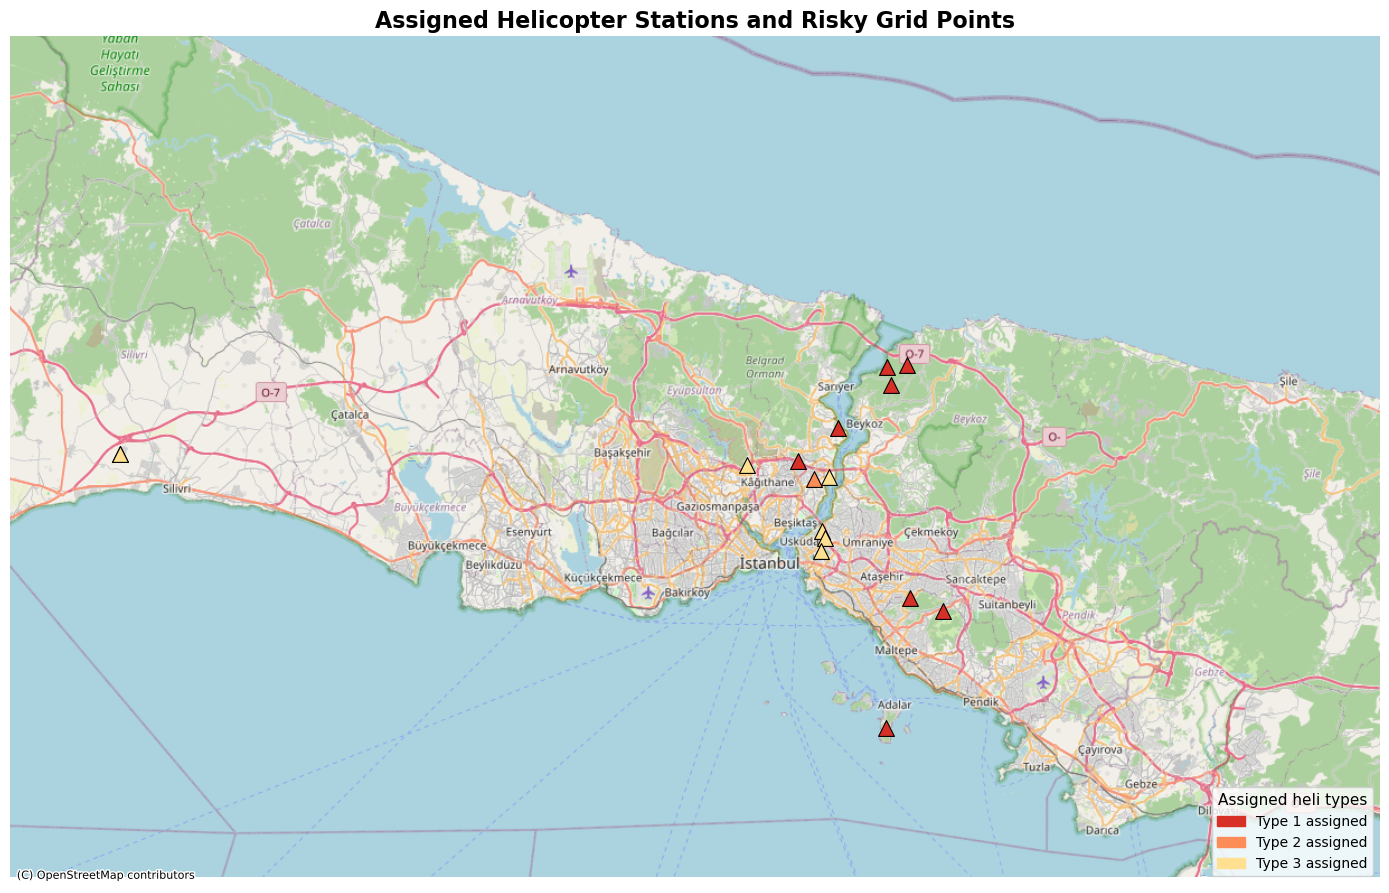

In [9]:
import contextily as ctx
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# Load station coordinates and grid points for mapping
gdf_stations = gpd.read_file("cleaned_data/helipads_clean.geojson", on_invalid="ignore").to_crs(epsg=4326)

df_grid = pd.read_csv("Grid_Coordinates.csv")
gdf_grid = gpd.GeoDataFrame(
    df_grid,
    geometry=gpd.points_from_xy(df_grid.lon, df_grid.lat),
    crs="EPSG:4326",
)

gdf_risky_grids = gdf_grid[gdf_grid["Grid_ID"].isin(top_grids)].copy()

# Get only stations that received a helicopter assignment from the MILP solution
assigned_station_ids = [i for i in station_ids if any(round(value(x[(i, k)]) or 0) >= 1 for k in HELI_TYPES)]

gdf_assigned = gdf_stations[gdf_stations["Station_ID"].isin(assigned_station_ids)].copy()
if gdf_assigned.empty:
    print("No stations were assigned a helicopter.")
else:
    # Determine heli type for each assigned station
    station_type = {}
    for i in assigned_station_ids:
        for k in HELI_TYPES:
            if round(value(x[(i, k)]) or 0) >= 1:
                station_type[i] = k
                break

    gdf_assigned["heli_type"] = gdf_assigned["Station_ID"].map(station_type)
    type_colors = {
        "Type_1": "#d73027",
        "Type_2": "#fc8d59",
        "Type_3": "#fee090",
    }
    gdf_assigned["color"] = gdf_assigned["heli_type"].map(type_colors)

    # Convert to Web Mercator for basemap
    gdf_risky_grids_3857 = gdf_risky_grids.to_crs(epsg=3857)
    gdf_assigned_3857 = gdf_assigned.to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(14, 10))

    gdf_risky_grids_3857.plot(
        ax=ax,
        color="lightgrey",
        markersize=8,
        alpha=0.35,
        edgecolor=None,
        zorder=1,
    )

    for heli_type, color in type_colors.items():
        mask = gdf_assigned_3857["heli_type"] == heli_type
        if mask.any():
            gdf_assigned_3857[mask].plot(
                ax=ax,
                marker="^",
                color=color,
                edgecolor="black",
                linewidth=0.8,
                markersize=130,
                label=heli_type,
                zorder=5,
            )

    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=10)

    bounds = pd.concat([gdf_risky_grids_3857.geometry, gdf_assigned_3857.geometry]).total_bounds
    xmin, ymin, xmax, ymax = bounds
    margin = 15000
    ax.set_xlim(xmin - margin, xmax + margin)
    ax.set_ylim(ymin - margin, ymax + margin)

    ax.set_title("Assigned Helicopter Stations and Risky Grid Points", fontweight="bold", fontsize=16)
    ax.axis("off")

    legend_handles = [
        mpatches.Patch(color=type_colors["Type_1"], label="Type 1 assigned"),
        mpatches.Patch(color=type_colors["Type_2"], label="Type 2 assigned"),
        mpatches.Patch(color=type_colors["Type_3"], label="Type 3 assigned"),
    ]
    plt.legend(handles=legend_handles, title="Assigned heli types", loc="lower right", fontsize=10, title_fontsize=11)
    plt.tight_layout()
    plt.show()